# Example: Pricing Zero-Coupon Treasury Bills Using NPV
This example computes zero-coupon U.S. Treasury bill prices using net present value (NPV).

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Represent and price zero-coupon cash flows:__ Identify the purchase-date outflow and the single par-value receipt at maturity, then apply the zero-NPV condition under an explicitly stated yield convention.
> * __Translate rate conventions and reconcile prices:__ Recover bank discount, investment, nominal, and continuously compounded rates from the same bill price, then use actual dates and Treasury's quotation formulas to convert the reported rate before applying the NPV model, and isolate the error caused by reusing an unconverted percentage.
> * __Relate bill prices and yields:__ Explain why a bill's price falls as its quoted investment rate rises, and compute that inverse relationship by perturbing the rate and repricing the bill.

We will price the bills and compare the model results with reported auction prices.

___

## Setup, Data, and Prerequisites
Load the computational environment from the `Include.jl` file.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Load the code environment.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
Use U.S. Treasury bill auction data from October 2022 onward, downloaded with the [TreasuryDirect auction query](https://www.treasurydirect.gov/auctions/auction-query/).

We load the dataset using [the `MyTreasuryBillDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTreasuryBillDataSet) exported by the `VLQuantitativeFinancePackage`, which returns the auction records as [a `DataFrame` instance](https://dataframes.juliadata.org/stable/), newest auction first. We store the data in the `dataset::DataFrame` variable.

> __Returned data:__ By default, the function [omits cash-management bills](https://www.treasurydirect.gov/marketable-securities/cash-management-bills/), which are irregular issues with terms quoted in days rather than weeks. Pass `cmb = true` to include them. The `from::Date` and `to::Date` keyword arguments restrict the auction-date range.

Load the auction records.

In [2]:
dataset = MyTreasuryBillDataSet()

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64
1,912797WC7,Bill,26-Week,08/24/2026,08/27/2026,02/25/2027,98.0839,0.03918
2,912797SU2,Bill,13-Week,08/24/2026,08/27/2026,11/27/2026,99.0506,0.03803
3,912797VM6,Bill,8-Week,08/20/2026,08/25/2026,10/20/2026,99.4314,0.03727
4,912797VD6,Bill,4-Week,08/20/2026,08/25/2026,09/22/2026,99.7169,0.03701
5,912797WG8,Bill,17-Week,08/19/2026,08/25/2026,12/22/2026,98.7604,0.0385
6,912797SA6,Bill,6-Week,08/18/2026,08/20/2026,10/01/2026,99.5747,0.03711
7,912797UZ8,Bill,13-Week,08/17/2026,08/20/2026,11/19/2026,99.0609,0.03802
8,912797TV9,Bill,26-Week,08/17/2026,08/20/2026,02/18/2027,98.089,0.03907
9,912797VL8,Bill,8-Week,08/13/2026,08/18/2026,10/13/2026,99.4299,0.03737


Store the number of auction records in `number_of_bills::Int64` using [the `nrow(...)` function from DataFrames.jl](https://dataframes.juliadata.org/stable/lib/functions/#DataAPI.nrow).

In [3]:
number_of_bills = nrow(dataset) # How many bills are in the dataset?

1145

___

## Task 1: Convert T-Bill Rates and Reproduce the Auction Price
A T-bill has two cash flows: the purchase price and the par amount paid at maturity. This task reconstructs one auction price, converts the reported rate to other conventions, and verifies that the NPV model reproduces the price.

Construct a [`DiscreteCompoundingModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) and store it in `discount_model`.

> The [`DiscreteCompoundingModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) has no data associated with it. Instead, it is used [by the Julia multiple dispatch system](https://docs.julialang.org/en/v1/manual/methods/#Methods) so that we call the correct pricing methods later.

Build the discount model.

In [4]:
discount_model = DiscreteCompoundingModel();

Build a zero-coupon Treasury bill model using [`MyUSTreasuryZeroCouponBondModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryZeroCouponBondModel) and the [`build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type,NamedTuple}).

> [The `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type,NamedTuple}) requires the model type and [a `NamedTuple`](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) of model data. We initially specify the par amount and $n=2$ compounding periods per year. The model's `rate` field must contain a nominal annual yield compatible with this compounding convention; Treasury's reported `Investment Rate` cannot be inserted there without conversion.

Store the zero-coupon model in `model::MyUSTreasuryZeroCouponBondModel`.

In [5]:
model = build(MyUSTreasuryZeroCouponBondModel, (
    par = 100.0, n = 2 # 100 USD par amount and semiannual yield compounding
));

We can use [the `typeof(...)` function](https://docs.julialang.org/en/v1/base/base/#Core.typeof) in combination with [the `fieldnames(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.fieldnames) to inspect the structure of our model, i.e., what data the model holds:

In [6]:
typeof(model) |> T -> fieldnames(T)

(:par, :rate, :T, :price, :n, :cashflow, :discount)

The zero-coupon package instance represents the two cash flows and applies a stated NPV convention, but it does not interpret Treasury bill quotations. The course dataset retains Treasury's reported `Investment Rate`, while the model expects a nominal annual yield compounded `n` times per year. Those rates are not numerically interchangeable.

Select a reproducible bill from the `dataset::DataFrame`. Let $D$ be its actual days to maturity, let $B$ be the number of days in the year following the issue date, and define $T=D/B$. Treasury's quotation helper converts the reported investment rate $y_I$ and actual dates into the price $V_B$. Once that price is known, the same two cash flows imply several rates:
$$
d=\left(1-\frac{V_B}{V_P}\right)\frac{360}{D},\qquad
R=\frac{V_P}{V_B}-1,\qquad
g=\frac{1}{T}\log\left(\frac{V_P}{V_B}\right),
$$
where $d$ is the bank discount rate, $R$ is the holding-period return, and $g$ is the continuously compounded annual growth rate. The price-implied nominal annual yield compounded $n$ times per year is
$$
y_n=n\left[\left(\frac{V_P}{V_B}\right)^{1/(nT)}-1\right].
$$
For a bill with no more than one half-year remaining, Treasury's investment rate is the simple annualization $y_I=R(B/D)$. Longer bills use Treasury's coupon-equivalent formula, which the quotation helper applies. See [Treasury's official auction formulas](https://www.treasurydirect.gov/files/laws-and-regulations/auction-regulations-uoc/auct-reg-gsr-356122303.pdf).

> __Conversion check:__ Reprice the bill with $y_n$ and the NPV model. The converted NPV price must equal the Treasury-convention price. Then insert the unconverted numerical value $y_I$ into the NPV model to measure the convention error.

Compute the rates and prices used below.

In [7]:
(example_bill, auction_price, treasury_price, reconciled_bill_model, naive_bill_model, rate_round_trip_table, price_comparison_table) = let

    # Initialize -
    selected_bill_index = 6; # fixed row keeps the worked example reproducible
    example_bill = dataset[selected_bill_index, :]; # selected Treasury auction record
    par = model.par; # par amount in USD
    n = model.n; # nominal-yield compounding periods per year
    auction_price = example_bill[:Price]; # published price per 100 USD of par
    investment_rate = example_bill[Symbol("Investment Rate")]; # Treasury coupon-equivalent quotation
    issue_date = Date(example_bill[Symbol("Issue Date")], dateformat"mm/dd/yyyy");
    maturity_date = Date(example_bill[Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
    days_to_maturity = Dates.value(maturity_date - issue_date); # actual days D
    days_in_following_year = Dates.value((issue_date + Year(1)) - issue_date); # 365 or 366 days B
    T = days_to_maturity / days_in_following_year; # actual-year fraction

    # Reconstruct the Treasury quotation price -
    treasury_price = treasury_bill_price_from_investment_rate(
        par, investment_rate, issue_date, maturity_date
    );

    # Convert the same price into comparable rates -
    bank_discount_rate = (1 - treasury_price / par) * 360 / days_to_maturity; # par-based, 360-day quote
    holding_period_return = par / treasury_price - 1; # return relative to cash invested
    simple_investment_rate = holding_period_return * days_in_following_year / days_to_maturity; # valid through one half-year
    continuous_rate = log(par / treasury_price) / T; # continuously compounded annual rate
    nominal_yield = n * ((par / treasury_price)^(1 / (n * T)) - 1); # nominal annual yield compounded n times

    # Reprice after conversion -
    reconciled_bill_model = deepcopy(model);
    reconciled_bill_model.T = T;
    reconciled_bill_model.rate = nominal_yield;
    reconciled_bill_model |> discount_model;

    # Deliberately reuse the unconverted investment rate -
    naive_bill_model = deepcopy(model);
    naive_bill_model.T = T;
    naive_bill_model.rate = investment_rate; # intentional convention mismatch
    naive_bill_model |> discount_model;

    # Package the comparison for display -
    rate_round_trip_table = DataFrame(
        convention = [
            "Bank discount rate d",
            "Reported Treasury investment rate y_I",
            "Price-implied simple investment rate",
            "Price-implied nominal yield y_n",
            "Price-implied continuous rate g"
        ],
        annual_rate_percent = 100 .* [
            bank_discount_rate, investment_rate, simple_investment_rate, nominal_yield, continuous_rate
        ]
    );
    price_comparison_table = DataFrame(
        method = [
            "Published auction price",
            "Treasury reconstruction from y_I",
            "NPV after conversion to y_n",
            "NPV using y_I without conversion"
        ],
        price_per_100_USD_par = [
            auction_price, treasury_price, reconciled_bill_model.price, naive_bill_model.price
        ],
        difference_from_treasury_per_100_USD_par = [
            auction_price - treasury_price, 0.0,
            reconciled_bill_model.price - treasury_price, naive_bill_model.price - treasury_price
        ]
    );

    (example_bill, auction_price, treasury_price, reconciled_bill_model, naive_bill_model,
        rate_round_trip_table, price_comparison_table); # return the round-trip objects
end;

### Compare the Rate Conventions
The table reports five annualized rates for the selected T-bill. The left column names the rate convention, and the right column gives the annual rate as a percentage. The first two rows report Treasury quotation conventions. The final three rows report rates implied by the reconstructed price under simple, nominal semiannual, and continuous compounding. All five rows describe the same purchase price and maturity payment; the numerical rates differ because the conventions use different denominators, day-count rules, and compounding rules.

In [8]:
pretty_table(rate_round_trip_table;
    column_labels = ["Rate convention", "Annual rate (%)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [2])])

======================================== ==================
                        Rate convention   Annual rate (%) 
======================================== ==================
                   Bank discount rate d            3.6446
  Reported Treasury investment rate y_I            3.7110
   Price-implied simple investment rate            3.7110
        Price-implied nominal yield y_n            3.7376
        Price-implied continuous rate g            3.7031
======================================== ==================


### Compare the Prices
The second table compares four price calculations. The published auction price and the Treasury reconstruction may differ slightly because the reported investment rate is rounded. The NPV price computed with the converted nominal yield should match the Treasury reconstruction. The final row shows the error caused by using the unconverted investment rate as a nominal yield.

In [9]:
pretty_table(price_comparison_table;
    column_labels = ["Method", "Price per 100 USD par", "Difference (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.6f", [2, 3])])

=================================== ======================= ===================
                            Method   Price per 100 USD par   Difference (USD) 
=================================== ======================= ===================
           Published auction price               99.574750          -0.000047
  Treasury reconstruction from y_I               99.574797           0.000000
       NPV after conversion to y_n               99.574797           0.000000
  NPV using y_I without conversion               99.577788           0.002991
=================================== ======================= ===================


> __Result:__ The converted NPV model reproduces the Treasury price. Only the unconverted rate creates a convention error.

The assertions below verify the two price matches and the deliberate mismatch.

In [10]:
@assert isapprox(auction_price, treasury_price; rtol = 1e-5) # reported quotation reproduces auction price
@assert isapprox(reconciled_bill_model.price, treasury_price; atol = 1e-12) # converted NPV yield closes the round trip
@assert !isapprox(naive_bill_model.price, treasury_price; atol = 1e-6) # unconverted rate creates a convention error

### Compare Convention Errors Across Bill Terms
Repeat the round trip for every regular bill in the dataset. For each auction, reconstruct the Treasury price, convert that price to the model's nominal semiannual yield, and verify that the reconciled NPV price returns to the Treasury price. Then reuse the unconverted investment rate in the NPV model and measure the resulting dollar error per $100$ of par.

> __Expected result:__ The convention error need not increase with maturity because the Treasury changes its investment-rate formula for bills longer than one half-year.

The hidden code constructs the complete `pricing_comparison_table::DataFrame`. The table summarizes the mean and maximum convention error per $100$ USD par for each bill term.

In [11]:
(pricing_comparison_table, convention_error_summary) = let

    # Initialize -
    comparison_rows = NamedTuple[]; # one rate-convention comparison per auction
    comparison_model = build(MyUSTreasuryZeroCouponBondModel, (
        par = 100.0, n = 2
    ));

    # Populate the auction comparisons -
    for i ∈ 1:number_of_bills
        auction_price = dataset[i, :Price]; # published price per 100 USD of par
        issue_date = Date(dataset[i, Symbol("Issue Date")], dateformat"mm/dd/yyyy");
        maturity_date = Date(dataset[i, Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
        investment_rate = dataset[i, Symbol("Investment Rate")];
        days_to_maturity = Dates.value(maturity_date - issue_date); # actual days D
        days_in_following_year = Dates.value((issue_date + Year(1)) - issue_date); # days B
        T = days_to_maturity / days_in_following_year; # actual-year fraction

        treasury_price = treasury_bill_price_from_investment_rate(
            comparison_model.par, investment_rate, issue_date, maturity_date
        );
        nominal_yield = comparison_model.n * (
            (comparison_model.par / treasury_price)^(1 / (comparison_model.n * T)) - 1
        ); # price-implied nominal annual yield

        # Reconcile after conversion -
        comparison_model.T = T;
        comparison_model.rate = nominal_yield;
        reconciled_price = comparison_model |> discount_model |> x -> x.price;

        # Measure the naive convention error -
        comparison_model.rate = investment_rate; # intentional mismatch
        naive_price = comparison_model |> discount_model |> x -> x.price;
        naive_error_per_100 = abs(naive_price - treasury_price);

        push!(comparison_rows, (
            CUSIP = dataset[i, :CUSIP],
            term = dataset[i, Symbol("Security Term")],
            days = days_to_maturity,
            investment_rate_percent = 100 * investment_rate,
            auction_price = auction_price,
            treasury_price = treasury_price,
            reconciled_npv_price = reconciled_price,
            naive_npv_price = naive_price,
            naive_error_USD_per_100_par = naive_error_per_100,
            reconciliation_error_per_100 = abs(reconciled_price - treasury_price)
        ));
    end

    # Summarize by standard bill term -
    pricing_comparison_table = DataFrame(comparison_rows);
    convention_error_summary = combine(
        groupby(pricing_comparison_table, :term),
        :days => minimum => :minimum_days,
        :days => maximum => :maximum_days,
        nrow => :auctions,
        :naive_error_USD_per_100_par => mean => :mean_naive_error_USD_per_100_par,
        :naive_error_USD_per_100_par => maximum => :maximum_naive_error_USD_per_100_par,
        :reconciliation_error_per_100 => maximum => :maximum_reconciliation_error_per_100
    );
    sort!(convention_error_summary, :minimum_days);

    @assert maximum(pricing_comparison_table.reconciliation_error_per_100) < 1e-10
    (pricing_comparison_table, convention_error_summary);
end;

summary_display = select(convention_error_summary, :term, :auctions,
    :mean_naive_error_USD_per_100_par, :maximum_naive_error_USD_per_100_par);
pretty_table(summary_display;
    column_labels = ["Term", "Auctions", "Mean error (USD/100 par)",
        "Maximum error (USD/100 par)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.6f", [3, 4])])

========== ========== ========================== ==============================
     Term   Auctions   Mean error (USD/100 par)   Maximum error (USD/100 par) 
========== ========== ========================== ==============================
   4-Week        203                   0.003350                      0.005607
   6-Week         79                   0.003451                      0.004390
   8-Week        203                   0.005558                      0.007956
  13-Week        204                   0.006534                      0.009105
  17-Week        201                   0.005966                      0.008322
  26-Week        204                   0.000096                      0.000379
  52-Week         51                   0.000165                      0.000372
========== ========== ========================== ==============================


___

## Task 2: Compute T-Bill Prices at Different Investment Rates
Malkiel proposed five theorems describing how fixed-income prices respond to yield and maturity:
* [Malkiel, B. G. (1962). Expectations, Bond Prices, and the Term Structure of Interest Rates. The Quarterly Journal of Economics, 76(2), 197–218](https://www.jstor.org/stable/1880816)

The first of these theorems is that, for fixed promised cash flows and a fixed quotation convention, T-bill/note/bond prices move inversely with yield. Here we perturb the reported investment rate and recompute price using the same Treasury convention and dates:
> __Theorem 1__: Bond prices move inversely to bond yields.

Malkiel proved Theorem 1 analytically. Here, we test the relationship computationally. Select a random bill from `dataset::DataFrame` using [Julia's `rand(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Base.rand). Use this bill to test __Theorem 1.__

In [12]:
random_bill_index = rand(1:number_of_bills)
println("Selected bill: $(random_bill_index)")

Selected bill: 1070


Display the selected T-bill.

In [13]:
dataset[random_bill_index,:] # what is the auction data for this bill?

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64
1070,912796Z69,Bill,8-Week,01/12/2023,01/17/2023,03/14/2023,99.3054,0.04559


Next, reconstruct the selected bill's Treasury-convention price and convert that price into the nominal semiannual yield expected by the package model. This conversion ensures that the model's purchase-date cash flow agrees with the quoted bill price.

The resulting `zero_coupon_model` stores the same two cash flows as the selected bill: the negative purchase price at time zero and the positive par payment at maturity. The reported investment rate remains available separately for the quotation perturbation.

See the [DataFrames.jl documentation for examples of accessing data from a `DataFrame` instance](https://dataframes.juliadata.org/stable/man/basics/). 

In [14]:
# Initialize the selected bill
selected_bill = dataset[random_bill_index, :];
selected_issue_date = Date(selected_bill[Symbol("Issue Date")], dateformat"mm/dd/yyyy");
selected_maturity_date = Date(selected_bill[Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
selected_investment_rate = selected_bill[Symbol("Investment Rate")]; # Treasury quotation
selected_days_to_maturity = Dates.value(selected_maturity_date - selected_issue_date);
selected_days_in_following_year = Dates.value((selected_issue_date + Year(1)) - selected_issue_date);
selected_T = selected_days_to_maturity / selected_days_in_following_year; # actual-year fraction

# Convert the Treasury price to the model yield
selected_treasury_price = treasury_bill_price_from_investment_rate(
    100.0, selected_investment_rate, selected_issue_date, selected_maturity_date
);
selected_nominal_yield = 2 * (
    (100.0 / selected_treasury_price)^(1 / (2 * selected_T)) - 1
); # nominal annual yield compounded semiannually

# Build the reconciled cash-flow model
zero_coupon_model = build(MyUSTreasuryZeroCouponBondModel, (
    par = 100.0, n = 2, T = selected_T, rate = selected_nominal_yield
)) |> discount_model;

#### Verify the Converted NPV Price
The Treasury reconstruction should match the published auction price within the rounding precision of the reported investment rate. After conversion, the NPV model should match the Treasury reconstruction to floating-point precision.

In [15]:
auction_price = selected_bill[:Price];
computed_price = selected_treasury_price; # retained as the Task 2 perturbation baseline
@assert isapprox(auction_price, computed_price; rtol = 1e-5)
@assert isapprox(zero_coupon_model.price, computed_price; atol = 1e-12)

#### Inspect the Cash Flows
The cash flow events for the T-bill are stored in the `cashflow::Dict{Int64, Float64}` dictionary of the zero-coupon model. For a zero-coupon T-bill, there are only two cash flows:

>__Zero-coupon cash flows:__ An initial investment (negative $V_{B}$ cash flow at time `0`), and the payoff of par value $V_{P}$ (positive cash flow) at maturity (at time `1`).

Display the cash flows.

In [16]:
zero_coupon_model.cashflow

Dict{Int64, Float64} with 2 entries:
  0 => -99.3054
  1 => 100.0

### Set the Investment-Rate Range
Let $y_I$ denote the Treasury **investment rate** reported in the auction data. This is a market quotation convention, not the course growth rate $g$. To simulate its price effect while holding all other inputs fixed, generate $y_I\leftarrow\beta y_I$. If $\beta<1$, the quoted investment rate decreases; if $\beta=1$, it is unchanged; and if $\beta>1$, it increases.

* First, we specify the number of perturbation values we want to consider; we store this value in the `number_of_samples` variable. If `number_of_samples` is odd, the perturbation range will include the reported investment rate as the center value.
* Next, we specify the lower and upper values of the perturbation range; the lower bound is stored in the `β₁` variable, while the upper bound is stored in the `β₂` variable.
* Finally, we compute the perturbation array (stored in the `β`-variable) using the [range function](https://docs.julialang.org/en/v1/base/math/#Base.range) in combination with the [Julia pipe |> operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping), and [the Julia collect function](https://docs.julialang.org/en/v1/base/collections/#Base.collect-Tuple{Type,%20Any}), which converts a range type to a collection, i.e., an array

Build the rate-scaling array.

In [17]:
number_of_samples = 7;
β₁ = 0.8;
β₂ = 1.2;
β = range(β₁, stop = β₂, length = number_of_samples) |> collect;

### Compute Prices at Different Investment Rates
Compute the price of the selected T-bill using different values of the quoted investment rate $y_I$ and store the results in the `theorem_1_simulation_array::Array{Float64,2}` variable. Iterate through each value of the $\beta$ array using a for loop, where we use the [eachindex function](https://docs.julialang.org/en/v1/base/arrays/#Base.eachindex). 

For iteration $i$ of the loop:
* Get a perturbation $\beta_i$ from the $\beta$ array and compute $y_{I,i}=\beta_i y_I$.
* Recompute price from the perturbed investment rate using the selected bill's unchanged issue and maturity dates
* Store the $\beta_{i}$ value in column 1 and the percentage difference in price in column 2 of the `theorem_1_simulation_array`
* Store the perturbed investment rate and new price in columns 3 and 4, respectively.

Run the simulation.

In [18]:
theorem_1_simulation_array = let

    # Initialize results matrix: [β_value, %_change, new_rate, new_price]
    theorem_1_simulation_array = Array{Float64,2}(undef, number_of_samples, 4);
    
    # Test Malkiel's Theorem 1 by perturbing interest rates
    for i ∈ eachindex(β)
        
        # Get perturbation factor for this iteration
        β_value = β[i];
        
        # Perturb Treasury's quoted investment rate: y_I,new = β * y_I
        y_I = selected_investment_rate;
        y_I_value = β_value * y_I;
        
        # Recompute with the same Treasury quotation convention
        new_price = treasury_bill_price_from_investment_rate(
            zero_coupon_model.par, y_I_value, selected_issue_date, selected_maturity_date
        );
        
        # Store results for analysis
        theorem_1_simulation_array[i,1] = β_value;  # Perturbation factor
        theorem_1_simulation_array[i,2] = ((new_price - computed_price)/(computed_price))*100;  # % price change
        theorem_1_simulation_array[i,3] = y_I_value;  # Perturbed investment rate
        theorem_1_simulation_array[i,4] = new_price;  # New price
    end
    theorem_1_simulation_array;
end

7×4 Matrix{Float64}:
 0.8        0.139114   0.036472   99.4435
 0.866667   0.0926998  0.0395113  99.3975
 0.933333   0.0463284  0.0425507  99.3514
 1.0        0.0        0.04559    99.3054
 1.06667   -0.0462855  0.0486293  99.2594
 1.13333   -0.0925282  0.0516687  99.2135
 1.2       -0.138728   0.054708   99.1676

### Plot Investment-Rate Changes Against Price Changes
`Unhide` the code block to see how we plotted the percentage change in the T-bill price versus the $\beta$ parameter, which scales the reported investment rate $y_I$. The case $\beta=1$ leaves the quotation unchanged, while $\beta<1$ decreases it and $\beta>1$ increases it.
> __Expected result:__ The T-bill price decreases as $\beta$, and therefore the quoted investment rate $y_I$, increases.

Display the plot.

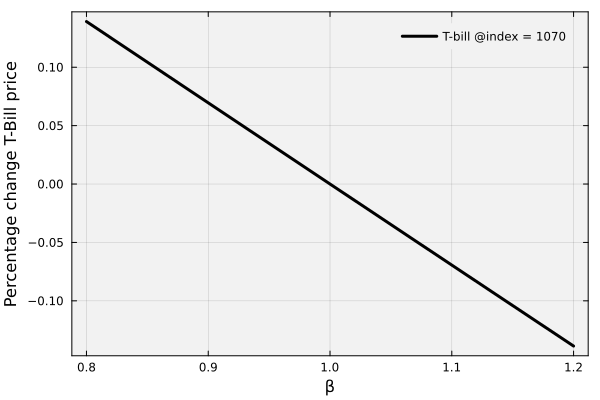

In [19]:
let
    q = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    plot(q, theorem_1_simulation_array[:,1], theorem_1_simulation_array[:,2], lw=3, c=:black, xlabel="β", 
            ylabel="Percentage change T-Bill price", label="T-bill @index = $(random_bill_index)")
end

### Verify That Price Falls as the Investment Rate Rises
If price is inversely related to the quoted investment rate, then the slope of price versus $y_I$ should be negative. Compute the slope from the simulation array and store it in `slope`.

> __Check:__ Use the [`@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to verify that the slope is negative. The test throws an [`AssertionError`](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) if the condition fails.

Compute and verify the slope.

In [20]:
slope = (theorem_1_simulation_array[end,4] - theorem_1_simulation_array[1,4])/(theorem_1_simulation_array[end,3] - theorem_1_simulation_array[1,3]);
@assert (slope < 0.0)  # Verify Theorem 1: negative slope confirms inverse price-yield relationship

___

## Summary

This example priced zero-coupon Treasury bills from their purchase-date outflow and single par-value payment at maturity, translated the same cash flows across rate conventions, and then examined how the quoted investment rate affects price.

> __Key Takeaways:__
>
> * __A T-bill has one terminal cash inflow:__ With no coupon payments, valuation reduces to discounting the par amount from maturity to the purchase date.
> * __Convert rate conventions before pricing:__ Bank discount, investment, nominal, and continuous rates use different annualization rules. Converting the Treasury quotation to the NPV model's nominal yield reproduces the Treasury price; using the unconverted percentage produces a convention error.
> * __Price and yield move inversely:__ Holding face value and maturity fixed, a larger quoted investment rate implies a lower purchase price; the perturbation experiment confirms the negative slope.

Treasury-bill valuation is mechanically simple, but accurate reconstruction and comparison require the price, dates, day-count basis, denominator, and compounding convention to be aligned.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Trade only with risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___